# Seleccion de Variables con Step Forward


En el presente notebook se generan y se evalúan los siguientes modelos.

* Regresión lineal
* Regresion lineal regularizada
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica

El preprocesamiento principal se realiza mediante una seleccion de variables utilizando step forwarding para regresion lineal. 

In [2]:
library(MASS)
library(leaps)
library(glmnet)
library(pracma)
library(raster)
library(ggplot2)
source("Utils.R")

Loading required package: Matrix

Loaded glmnet 4.1-2


Attaching package: ‘pracma’


The following objects are masked from ‘package:Matrix’:

    expm, lu, tril, triu


Loading required package: sp


Attaching package: ‘raster’


The following objects are masked from ‘package:MASS’:

    area, select




In [3]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

StScaler <- import("sklearn.preprocessing", convert = FALSE)$StandardScaler
MMScaler <- import("sklearn.preprocessing", convert = FALSE)$MinMaxScaler

In [4]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y

hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

### Mediante KFold con K=40 elegimos la mejor cantidad de variables (que no sobreajuste)

In [5]:
predict.regsubsets = function(object,newdata,id,...){
      form = as.formula(object$call[[2]]) # Extract the formula used when we called regsubsets()
      mat = model.matrix(form,newdata)    # Build the model matrix
      coefi = coef(object,id=id)          # Extract the coefficiants of the ith model
      xvars = names(coefi)                # Pull out the names of the predictors used in the ith model
      mat[,xvars]%*%coefi               # Make predictions using matrix multiplication
}

In [6]:
setSeed()

n = nrow(TRAIN_X)
k = 40

nvmax=n-n/k
resultados <- matrix(0, nrow=k, ncol = nvmax-1)

X = TRAIN_X

indices = obtener_indices_kfold(n, k)
a=1
for(i in indices){
    DF_train = X[-i,]
    DF_train$Y = TRAIN_Y[-i]

    DF_test = X[i,]
    DF_test$Y = TRAIN_Y[i]
    
    forw <- regsubsets(Y~., data=DF_train, method = "forward", nvmax=nvmax-1)
    
    for(j in 1:(nvmax-1)){
        Y_pred = predict(forw, DF_test, id=j)
        resultados[[a, j]] = mean( (DF_test$Y - Y_pred)^2 )
    }
    a=a+1
    message(progreso(a, 1:k))
}

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 7.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 10 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 12.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 15 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 17.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = 

In [7]:
result <- as.data.frame(resultados)
colnames(result) <- seq(1, 155)

In [8]:
a <- as.data.frame(t(apply(result, 2, summary)))
a$ind = seq(1,155)
colnames(a) <- c("min", "q1", "median", "mean", "q3", "max", "ind")

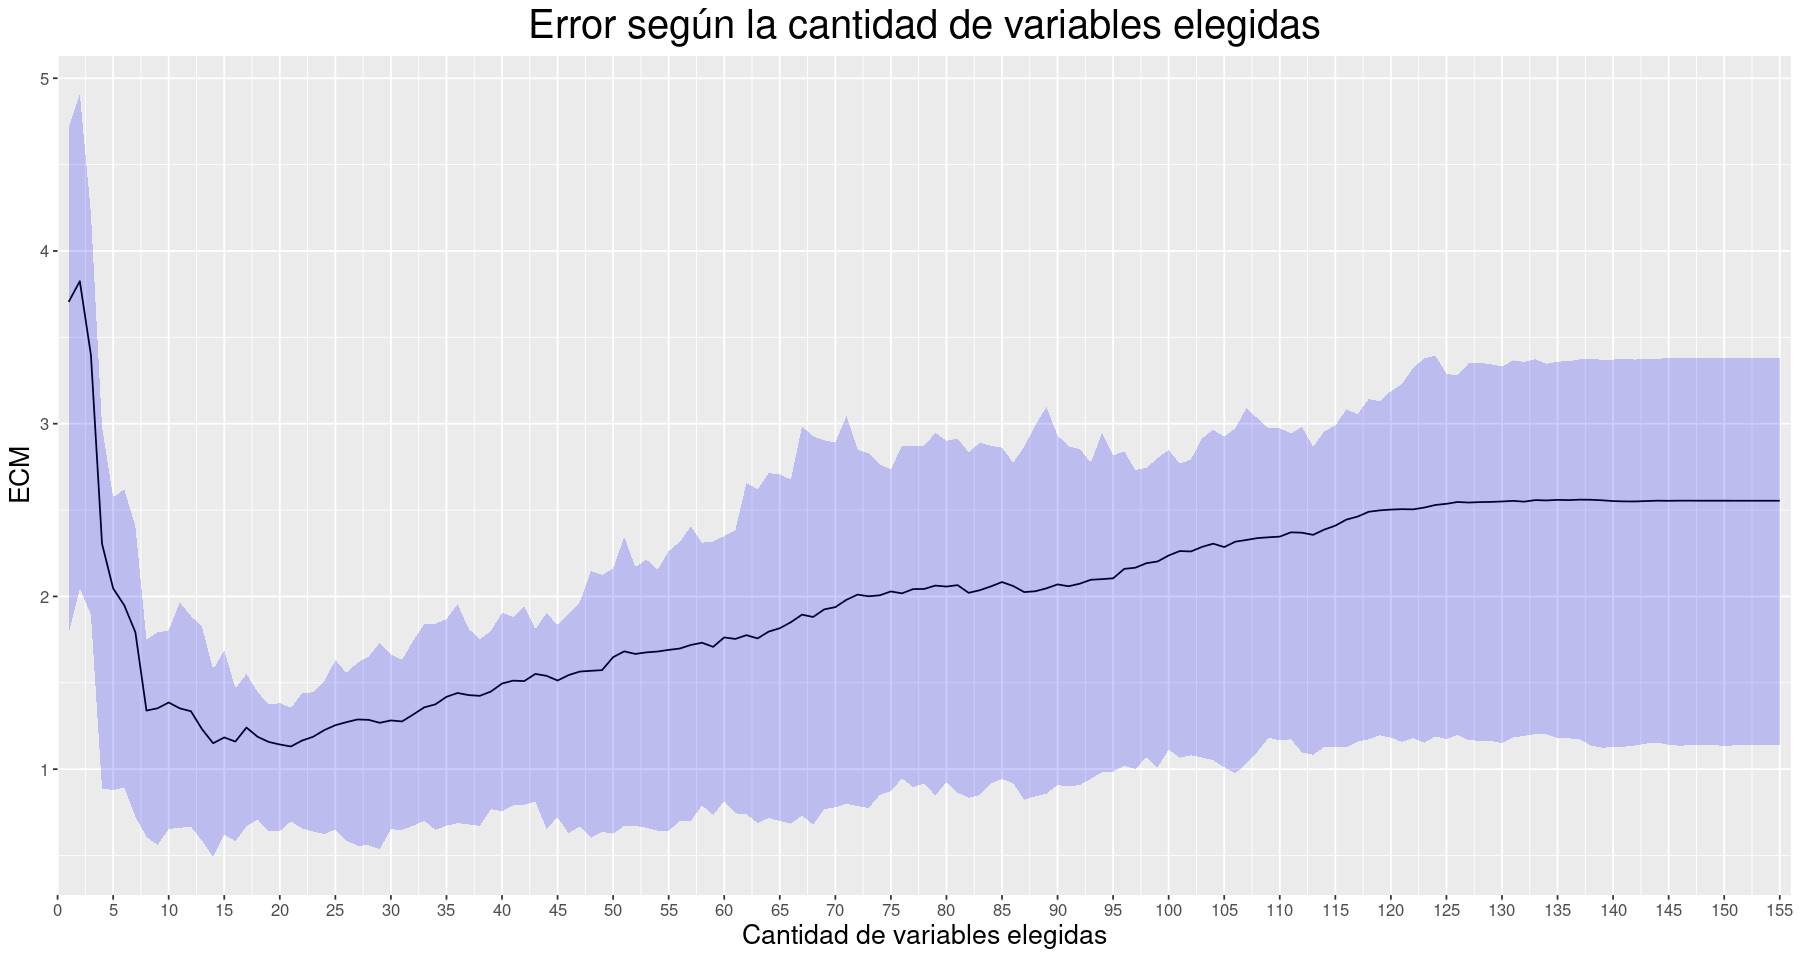

In [9]:
options(repr.plot.width=15, repr.plot.height=8)
theme_update(plot.title = element_text(hjust = 0.5, size = 24),
                          axis.text=element_text(size=10),
                          axis.title=element_text(size=16))

ggplot(a, aes(x=ind, y=mean)) +
    geom_line() +
    geom_ribbon(aes(ymin=q1, ymax=q3), fill="blue", alpha=0.2) +
    scale_x_continuous(breaks = seq(0, 155, by=5), expand = c(0, 1))+
    ggtitle("Error según la cantidad de variables elegidas") + 
    xlab("Cantidad de variables elegidas") + ylab("ECM")

Vemos en este gráfico que entre 10 y 30 el error se comporta de forma similar, para luego empezar a overfittear, por lo que haremos ahora un gráfico más detallado sobre esta zona.

In [10]:
setSeed()

n = nrow(TRAIN_X)
k = n

nvmax=30
nvmin=10
resultados <- matrix(0, nrow=k, ncol = nvmax)

X = TRAIN_X

indices = obtener_indices_kfold(n, k)
a=1
for(i in indices){
    DF_train = X[-i,]
    DF_train$Y = TRAIN_Y[-i]

    DF_test = X[i,]
    DF_test$Y = TRAIN_Y[i]
    
    forw <- regsubsets(Y~., data=DF_train, method = "forward", nvmax=nvmax)
    
    for(j in nvmin:nvmax){
        Y_pred = predict(forw, DF_test, id=j)
        resultados[[a, j]] = mean( (DF_test$Y - Y_pred)^2 )
    }
    a=a+1
    message(progreso(a, 1:k))
}

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 1.2 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 1.9 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 2.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 3.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 3.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 4.4 %

Warning message in leaps.setup(x, y, wt = wt, nbest 

El progreso es del 33.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 33.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 34.4 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 35 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 35.6 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 36.2 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 36.9 %

Warning message in le

El progreso es del 65.6 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 66.2 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 66.9 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 67.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 68.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 68.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 69.4 %

Warning message in 

El progreso es del 98.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 98.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 99.4 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 100 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
???



In [11]:
result <- as.data.frame(resultados[, 10:30])
colnames(result) <- seq(10, 30)

In [12]:
a <- as.data.frame(t(apply(result, 2, summary)))
a$ind = seq(10, 30)
colnames(a) <- c("min", "q1", "median", "mean", "q3", "max", "ind")

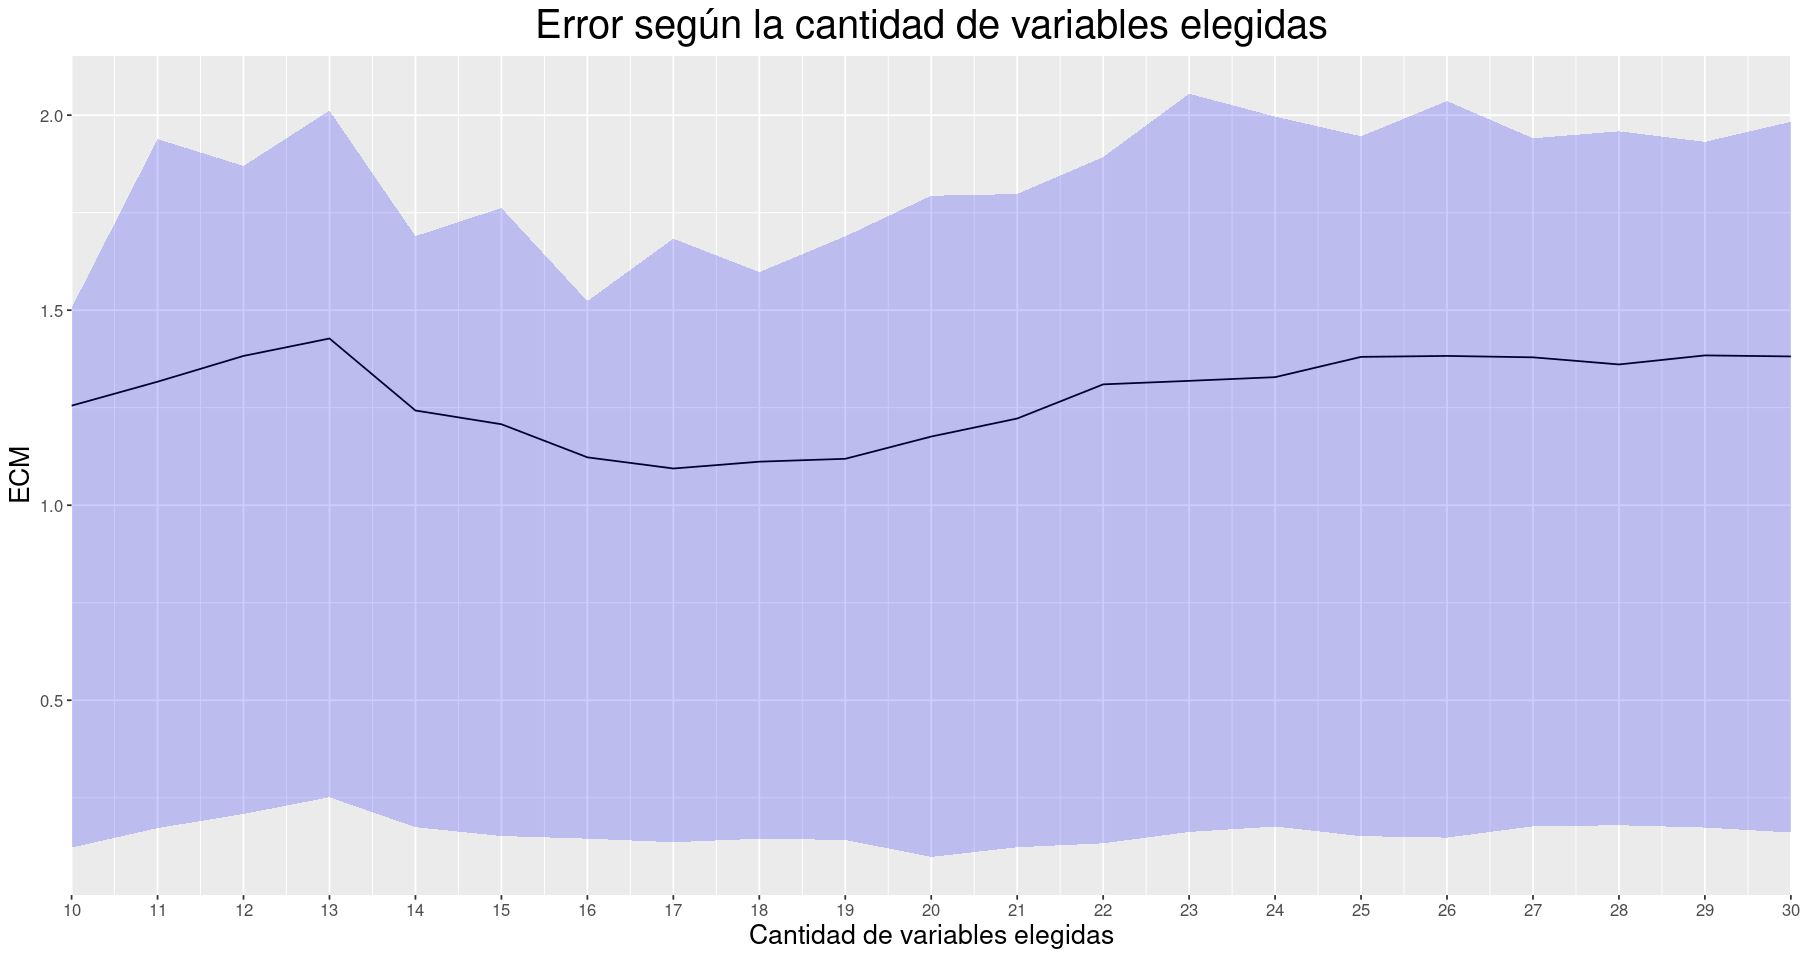

In [13]:
options(repr.plot.width=15, repr.plot.height=8)
theme_update(plot.title = element_text(hjust = 0.5, size = 24),
                          axis.text=element_text(size=10),
                          axis.title=element_text(size=16))

ggplot(a, aes(x=ind, y=mean)) +
    geom_line() +
    geom_ribbon(aes(ymin=q1, ymax=q3), fill="blue", alpha=0.2) +
    scale_x_continuous(breaks = seq(10, 30, by=1), expand = c(0, 0))+
    ggtitle("Error según la cantidad de variables elegidas") + 
    xlab("Cantidad de variables elegidas") + ylab("ECM")

Nos quedamos entonces con 17, pues es el valor con menor ECM por LOOCV

## Las variables elegidas

In [15]:
n = nrow(TRAIN_X)

forw <- regsubsets(Y~., data = TRAIN_DF, method = "forward", nvmax = 17)

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“142  linear dependencies found”


In [16]:
vs <- names(which(summary(forw)$which[17, ])[2:18])
vs

[1] "V1"   "V6"   "V8"   "V36"  "V59"  "V70"  "V74"  "V88"  "V112" "V126"
[11] "V133" "V142" "V143" "V193" "V235" "V242" "V243"

In [17]:
SELECTED_TRAIN_X = TRAIN_DF[, vs]
SELECTED_TRAIN_DF = SELECTED_TRAIN_X
SELECTED_TRAIN_DF$Y = TRAIN_Y

SELECTED_HOLDOUT_X = HOLDOUT_DF[, vs]
SELECTED_HOLDOUT_DF = SELECTED_HOLDOUT_X
SELECTED_HOLDOUT_DF$Y = HOLDOUT_Y

# Modelo 1: regresion Lineal

In [18]:
# No escalamos los datos porque no hay regularizacion.
modelo1 <- lm(Y~., data = SELECTED_TRAIN_DF)

Y_pred = predict(modelo1, SELECTED_TRAIN_X)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(SELECTED_TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.539609005425229"


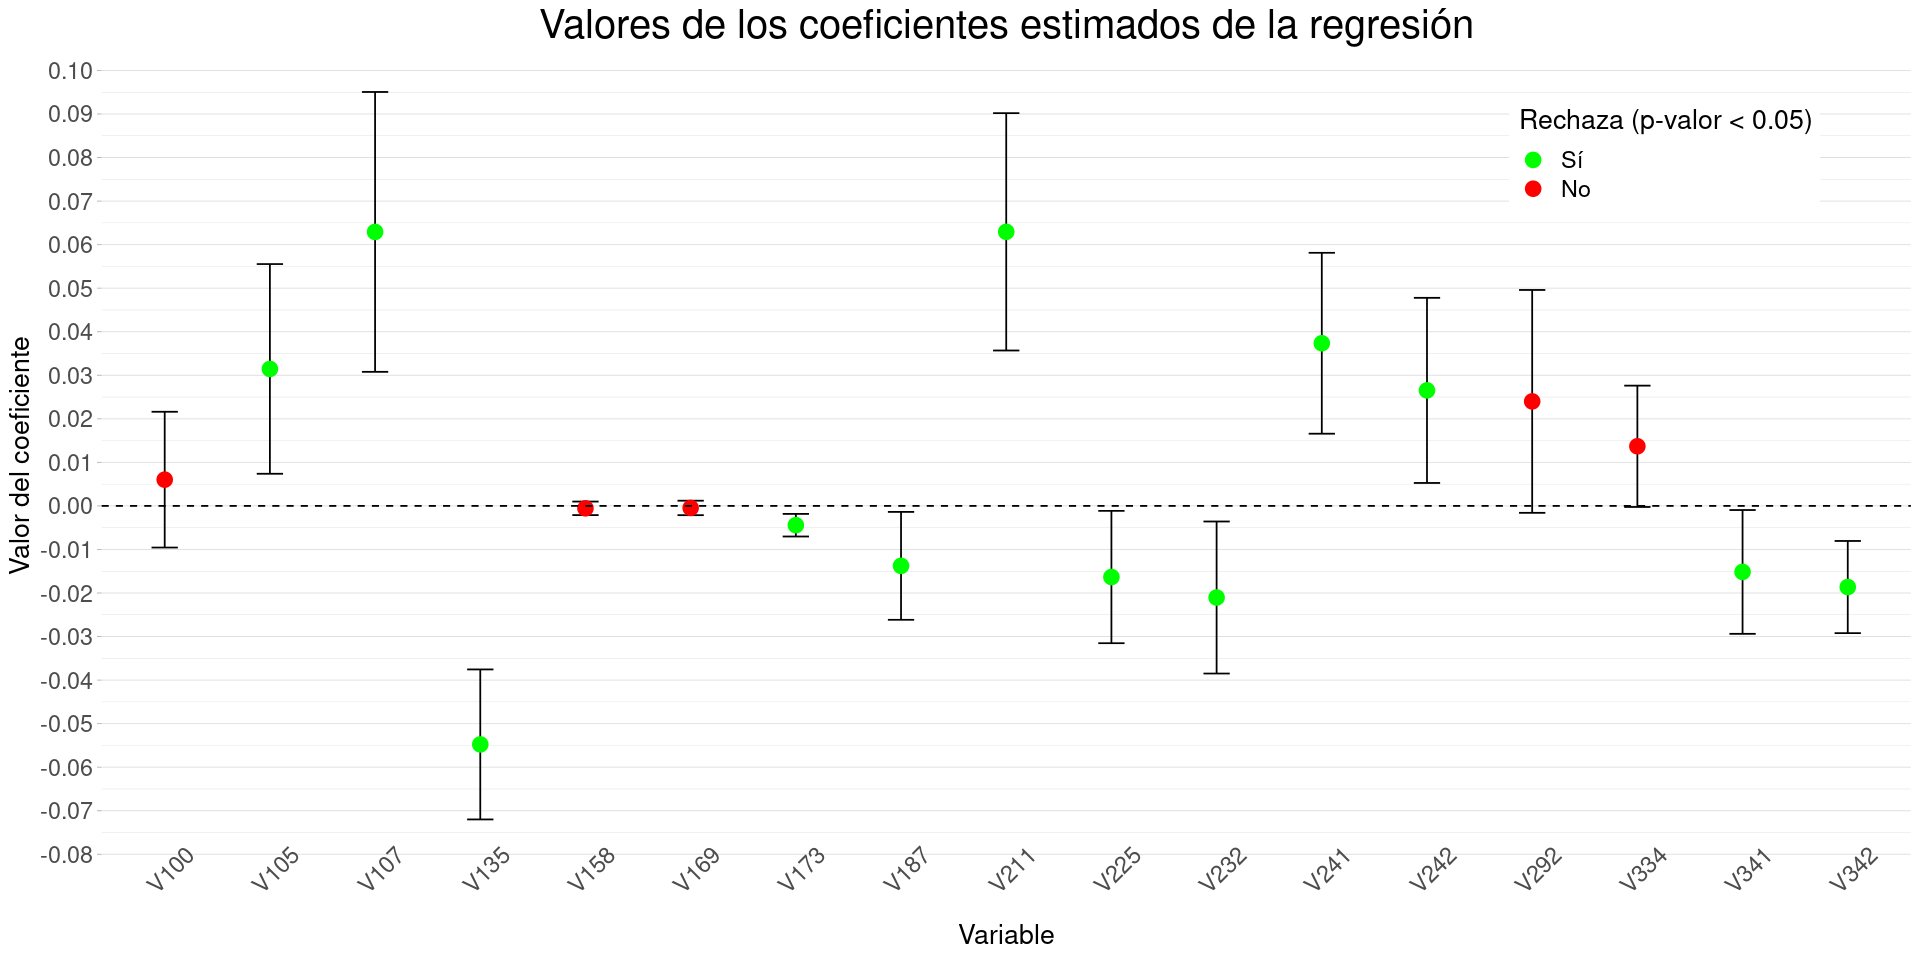

In [20]:
a <- summary(modelo1)
x_plot = paste("V", as.integer(sub('.', '', colnames(SELECTED_TRAIN_X))) + 99, sep="")
data_plot <- data.frame(
    x=x_plot,
    y=a$coefficients[-1, 1],
    sd=a$coefficients[-1, 2],
    col=(a$coefficients[-1, 4] < 0.05)
)
colnames(data_plot) <- c("V", "Estimate", "SD", "Rechaza")

options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x = V, y = Estimate)) + 
  ggtitle("Valores de los coeficientes estimados de la regresión") +
  geom_errorbar(aes(ymin = Estimate - 2*SD, ymax = Estimate + 2*SD),  width=0.25) +
  geom_point(aes(color = Rechaza), size = 4) + 
  theme_light() +
  scale_colour_manual(values = c("TRUE" = "green", "FALSE" = "red"),
                      labels = c("Sí", "No"), breaks = c("TRUE", "FALSE")) + 
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text.y=element_text(size=14),
        axis.text.x=element_text(size=14, angle = 45),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = c(.95, .95),
        legend.justification = c("right", "top"),
        legend.box.just = "right",
        legend.margin = margin(6, 6, 6, 6),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14)) +
  geom_hline(yintercept=0, linetype="dashed") + 
  guides(color=guide_legend("Rechaza (p-valor < 0.05)")) +
  scale_y_continuous(breaks = seq(-1, 1, by=0.01)) +
  xlab("Variable") + ylab("Valor del coeficiente")

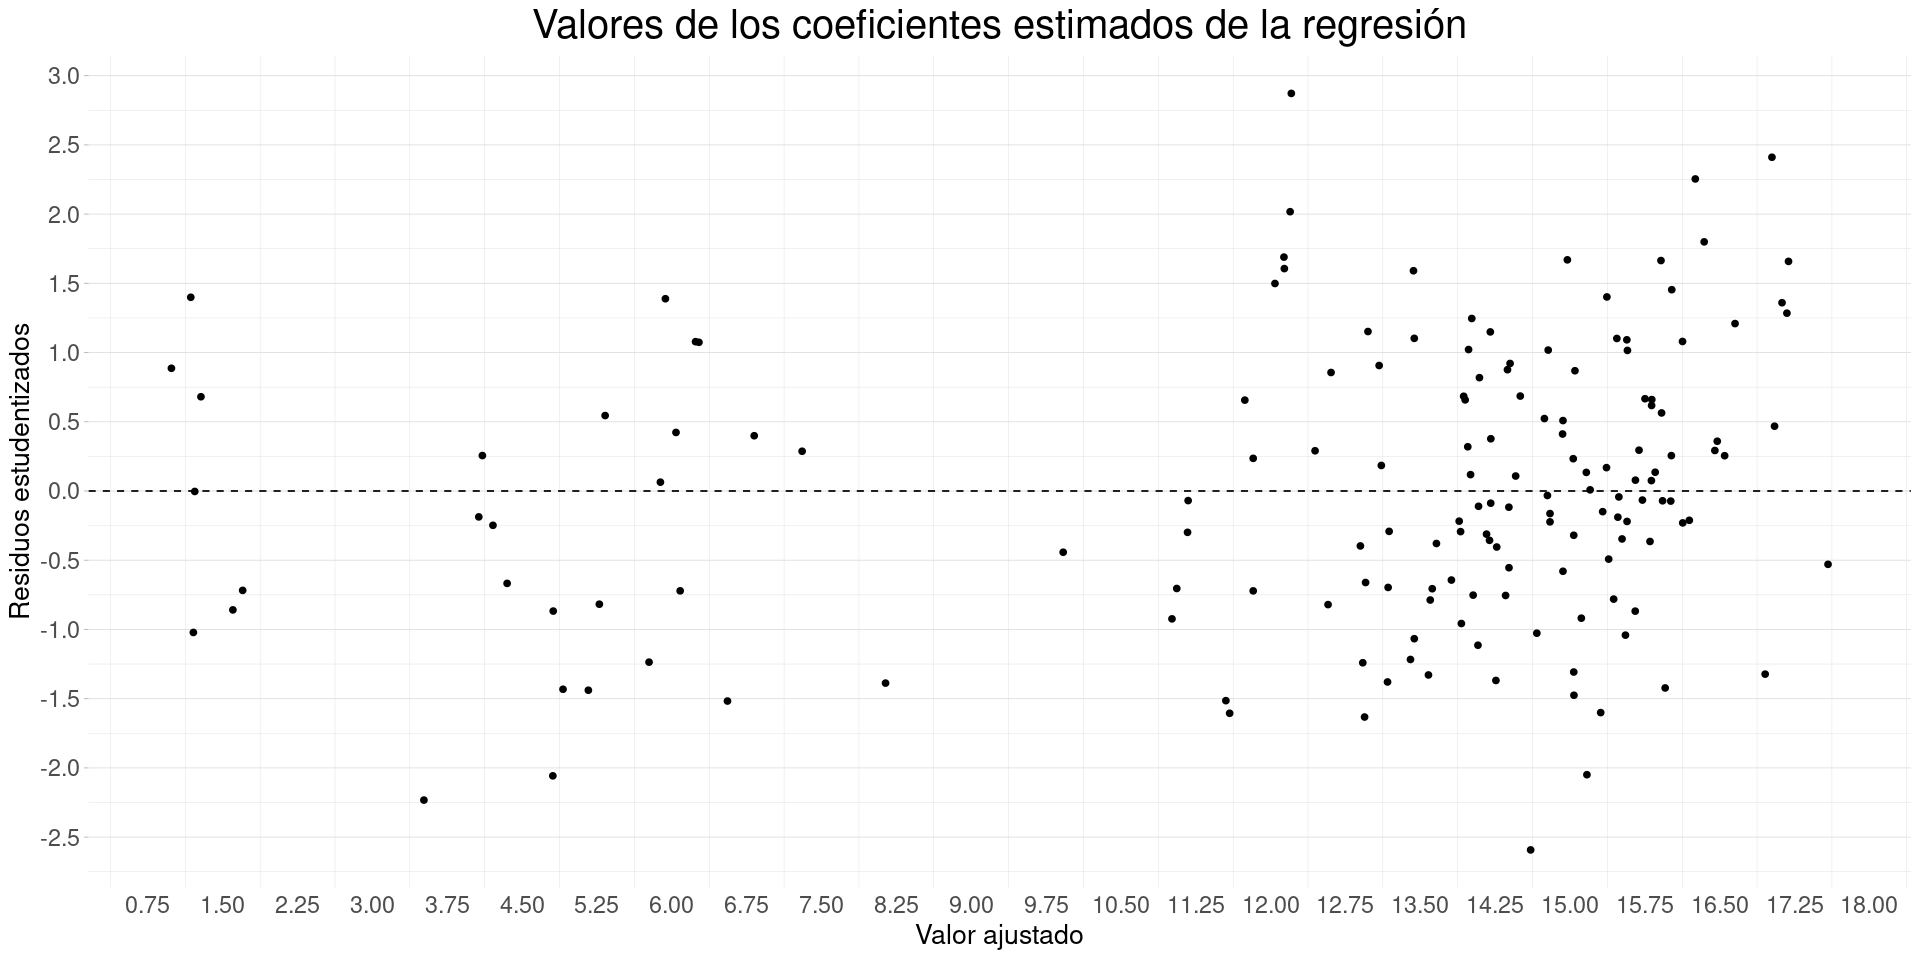

In [22]:
b <- data.frame(
    "y" = SELECTED_TRAIN_DF$Y,
    "tmenosi" = studres(modelo1)
)
options(repr.plot.width=16, repr.plot.height=8)
ggplot(b, aes(x=y, y=tmenosi)) +
    ggtitle("Valores de los coeficientes estimados de la regresión") +
    geom_point()+
    theme_light() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
    geom_hline(yintercept=0, linetype="dashed") + 
    scale_x_continuous(breaks = seq(0, 20, by=0.75)) +
    scale_y_continuous(breaks = seq(-4, 4, by=0.5)) + 
    xlab("Valor ajustado") + ylab("Residuos estudentizados")

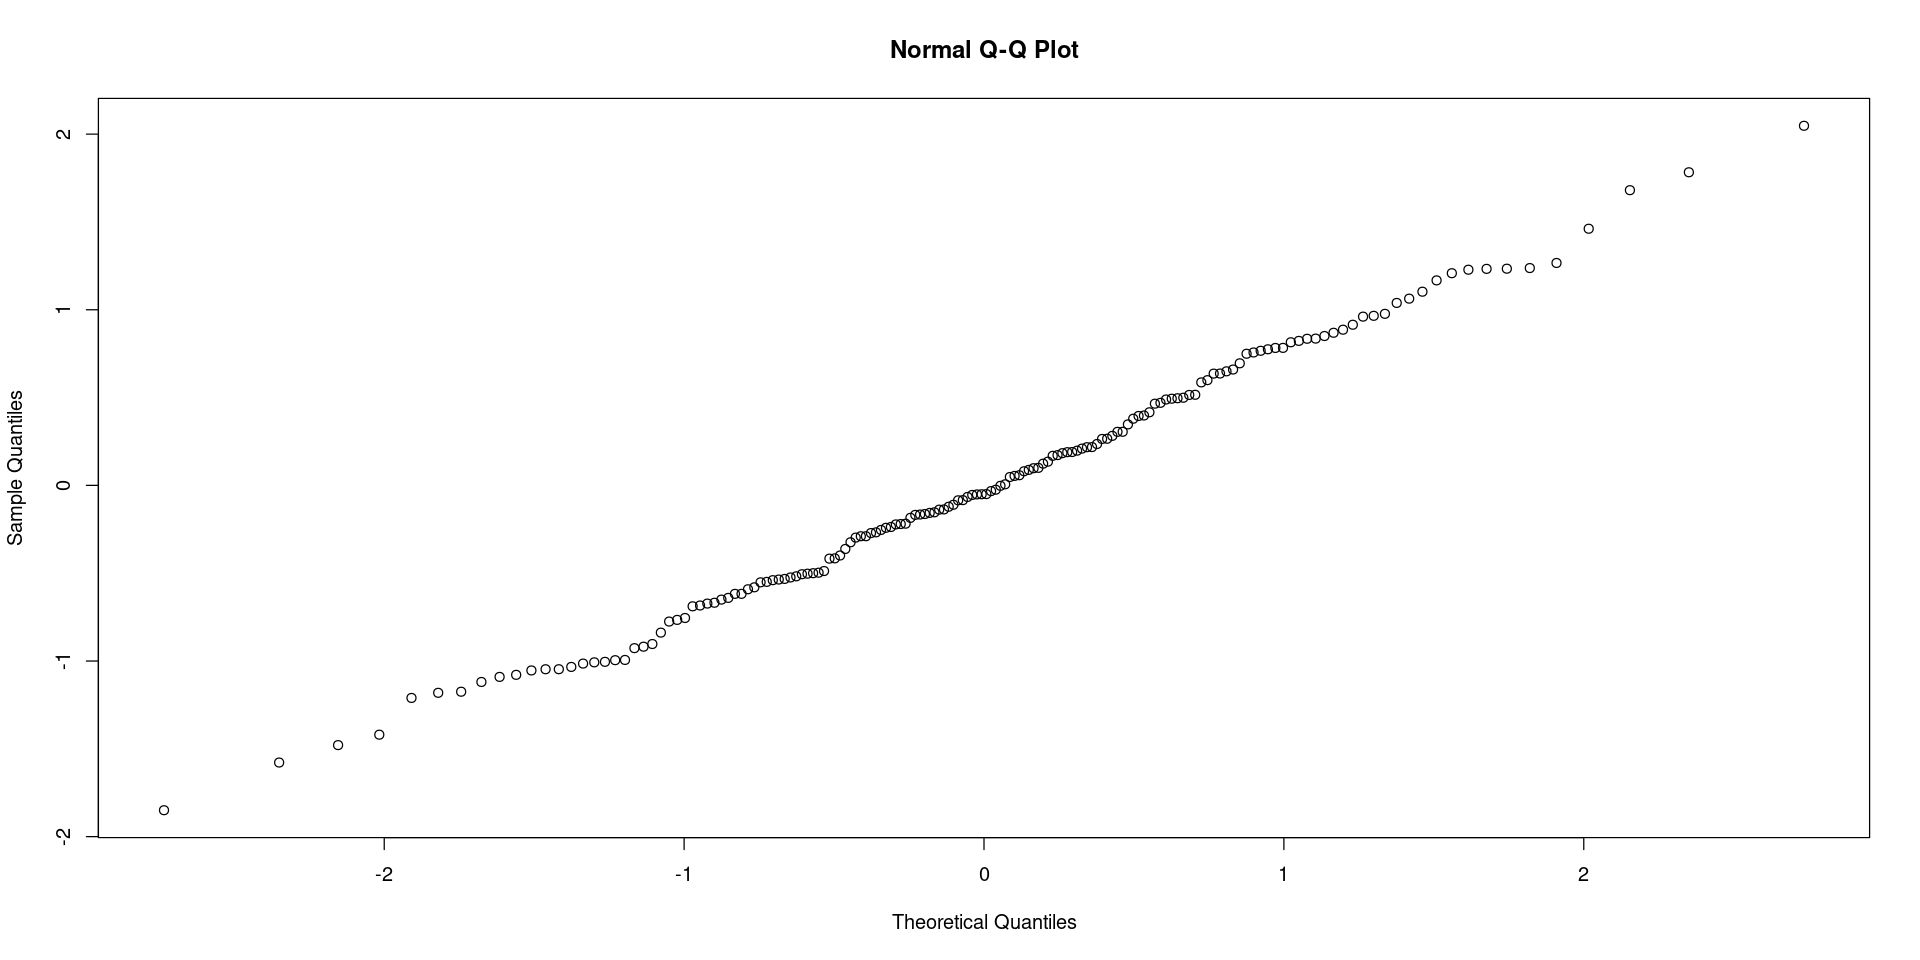

In [23]:
data_plot <- as.data.frame(qqnorm(modelo1$residuals))

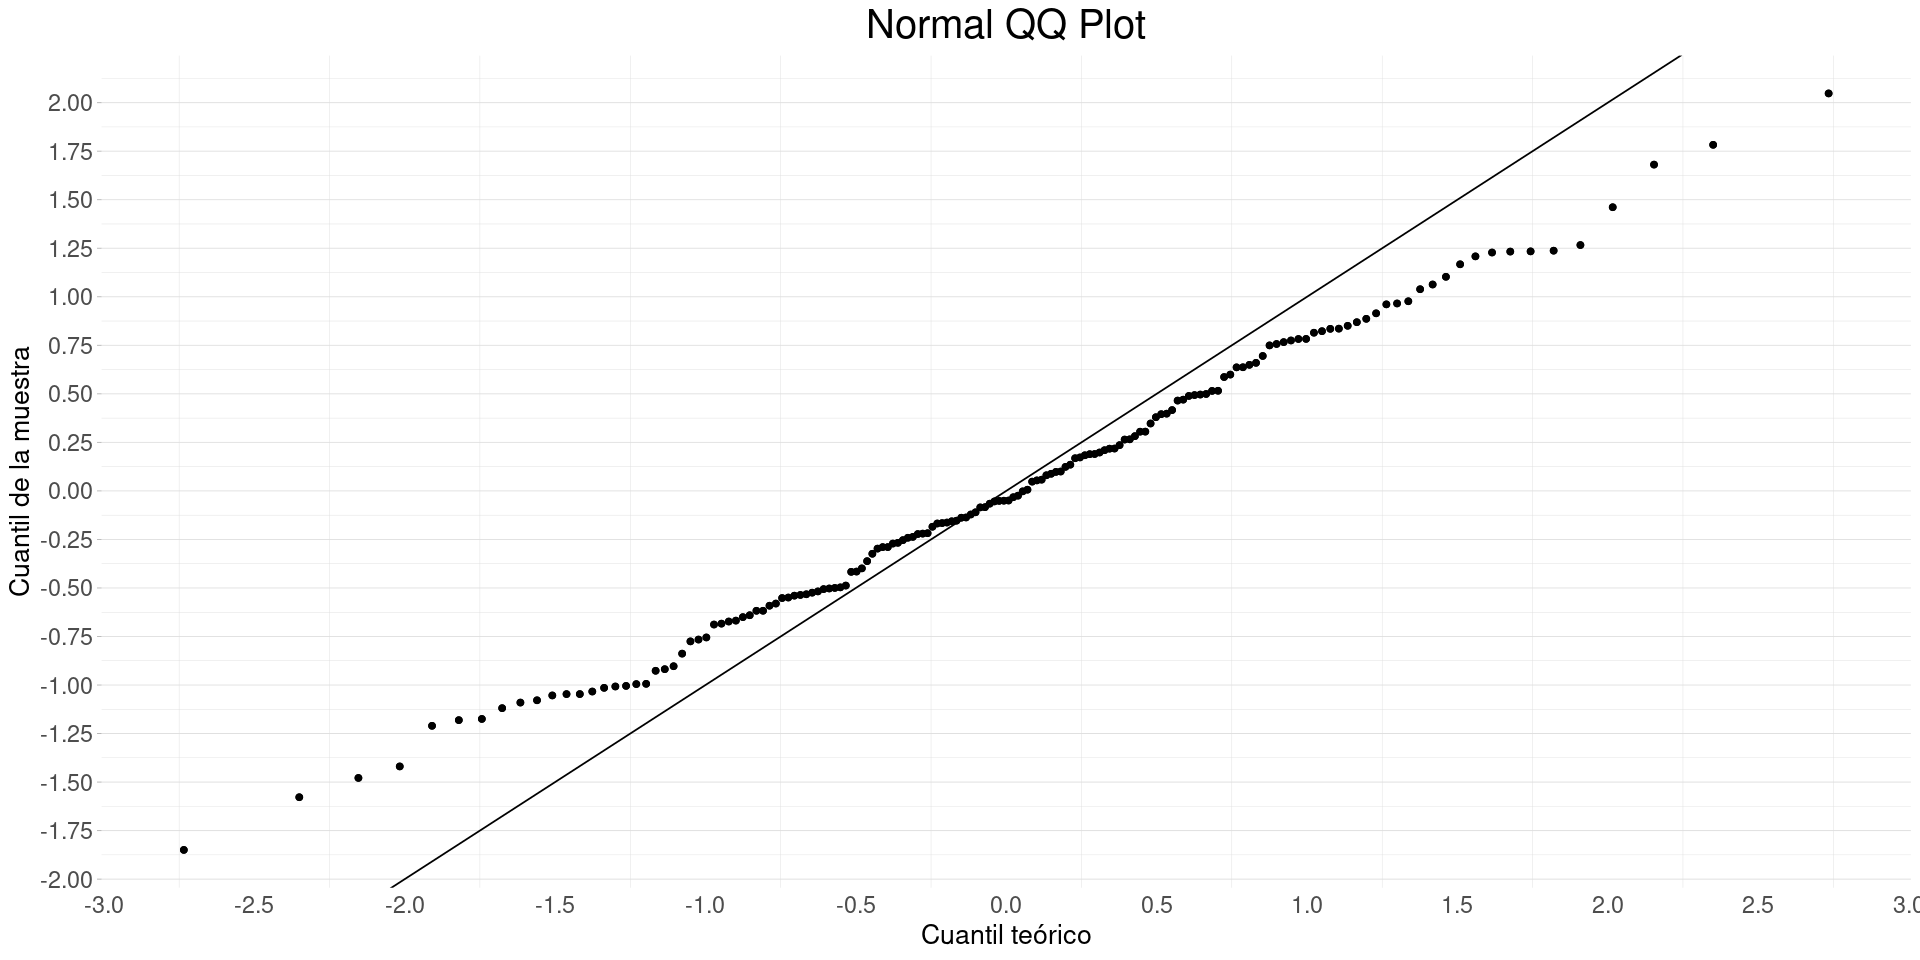

In [24]:
options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x=x, y=y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0) +
    ggtitle("Normal QQ Plot") +
    geom_point()+
    theme_light() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
    xlab("Cuantil teórico") + ylab("Cuantil de la muestra")+
    scale_x_continuous(breaks = seq(-5, 5, by=0.5)) +
    scale_y_continuous(breaks = seq(-2, 2, by=0.25))

In [ ]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    df_train = X[-i,]
    df_train$Y = TRAIN_Y[-i]
    
    X_test = X[i,]
    Y_test = TRAIN_Y[i]

    model <- lm(Y~.,  data = df_train)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
p = ncol(SELECTED_TRAIN_X)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

# Modelo 2: regresion Lineal Regularizada

In [ ]:
setSeed()
n = nrow(SELECTED_TRAIN_X)
k = 10
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Escalador = integer(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

alphas <- seq(0, 1, 0.05)
lambdas <- logspace(-10, 3, 30)
escaladores <- c(StScaler(), MMScaler())


for (alpha in alphas) {
    for (lambda in lambdas) {
        for(s in 1:length(escaladores)){
            escalador = escaladores[[s]] 
            err = 0
            for (i in indices) {
                X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                Y_train = TRAIN_Y[-i]

                X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                Y_test = TRAIN_Y[i]

                model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
                Y_pred = predict(model, X_test_scaled)
                err = err + sum((Y_test - Y_pred)^2)
            }
            resultados = rbind(resultados, list(alpha, lambda, s, err/n))
        }
    }
    message(progreso(alpha, alphas))
}

colnames(resultados)  <- c("alpha", "lambda", "Escalador", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

##### Calculo del error por LOOCV

In [ ]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
escalador = escaladores[[mejores_parametros$Escalador]]
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
X_train_scaled <- as.matrix(escalador$fit_transform(X))
modelo2 <- glmnet(X_train_scaled, TRAIN_Y, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)

p = sum(modelo2$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

In [ ]:
p

# Modelo 3: árbol de regresión

In [ ]:
library(rpart)
library(rpart.plot)

In [ ]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  CP       =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X

minsplits <- c(2, 5, 10, 20, 30, 50)
maxdepths <- c(4, 5, 6, 7, 8)
cps <- c(0.0005, 0.001, 0.005, 0.01, 0.015, 0.025)
for (minsplit in minsplits) {
    for (maxdepth in maxdepths) {
        for (cp in cps) {
            parametros = rpart.control(minsplit=minsplit, maxdepth=maxdepth, cp=cp)
            err = 0
            for(i in indices) {
                DF_train = X[-i,]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,]
                DF_test$Y = TRAIN_Y[i]
                
                model <- rpart(Y ~ ., data = DF_train, control=parametros, xval=1)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, cp, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "CP", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

In [ ]:
parametros <- rpart.control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, cp=mejores_parametros$CP)

modelo3 <- rpart(Y ~ ., data = SELECTED_TRAIN_DF, control=parametros)

In [ ]:
rpart.plot(modelo3, digits=4)
title("Modelo 21")

In [ ]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    train_df <- X[-i,]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- rpart(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
a <- summary(modelo3)

In [ ]:
p = length(unique(a$frame$var))-1
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

# Modelo 4: KNN

In [ ]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

In [ ]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    S        =integer(),
    Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X
escaladores <- c(StScaler(), MMScaler())
for(K in 1:10){
    for(w in c(1, 2)){
        wei = ifelse(w==1, "uniform", "distance")
        for(p in c(1, 2)){
            for(s in 1:length(escaladores)){
                escalador = escaladores[[s]]
                err = 0
                for(i in indices){
                    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                    Y_train = TRAIN_Y[-i]

                    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                    Y_test = TRAIN_Y[i]
                    
                    model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)
                    Y_pred = as.double(model$predict(X_test_scaled))
                    err = err + sum((Y_test - Y_pred)^2)
                }
                resultados = rbind(resultados, list(K, w, p, s, err/n))
            }
        }
    }
    message(progreso(K, 1:10))
}
colnames(resultados)  <- c("K", "Weights", "Distance", "Escalador", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

In [ ]:
escalador = MMScaler()
X_train_scaled = as.matrix(escalador$fit_transform(X))
Y_train = TRAIN_Y
modelo4 = knnr(n_neighbors=as.integer(2),
                p=1,
                weights="distance")
modelo4 = modelo4$fit(X_train_scaled, Y_train)

In [ ]:
modelo4

Calculo del error

In [ ]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
escalador = escaladores[[mejores_parametros$Escalador]]
wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, Y_train)
    Y_pred = as.double(model$predict(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
p = 17
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

# Modelo 5: regresión no paramétrica

In [ ]:
D <- function(x, y) (sum((abs(x-y))))
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}

In [ ]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

resultados <- data.frame(
    h       =double(),
    K       =integer(),
    Error   =double()
)
escalador = StScaler()

hs = seq(0.1, 15, l=30)
Ks = list((function(x) (0.5 * (abs(x)<1))),
          (function(x) (dnorm(x))),
          (function(x) (0.75*(1-x^2)*(abs(x)<1))),
          (function(x) ((15/16)*((1-x^2)^2)*(abs(x)<1)))
       )

for(h in hs){
    for(Knumber in 1:length(Ks)){
        K = Ks[[Knumber]]
        err = 0
        for(i in indices){
            X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
            Y_train = TRAIN_Y[-i]

            X_test_scaled = as.matrix(escalador$transform(X[i, ]))
            Y_test = TRAIN_Y[i]
            
            Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(h, Knumber, err/n))
    }
    message(progreso(h, hs))
}
colnames(resultados)  <- c("h", "K", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

In [ ]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
escalador = StScaler()
K = Ks[[mejores_parametros$K]]
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    
    Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, mejores_parametros$h, K)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

In [ ]:
p = 17
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

# Predicciones sobre HoldOut

In [ ]:
# Funcion de error
err <- function(y, ypred){
    mean((y-ypred)^2)
}

In [ ]:
# Modelo 1
modelo1 <- lm(Y~., data = SELECTED_TRAIN_DF)
Y_pred <- predict(modelo1, newdata=SELECTED_HOLDOUT_DF)
err(HOLDOUT_Y, Y_pred)

In [ ]:
# Modelo 2
escalador=MMScaler()
X_train_scaled <- as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
X_test_scaled <- as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
modelo2 <- glmnet(X_train_scaled, TRAIN_Y, lambda=0.01172102, alpha=0)
Y_pred <- as.double(predict(modelo2, X_test_scaled))
err(HOLDOUT_Y, Y_pred)

In [ ]:
# Modelo 3
parametros <- rpart.control(minsplit=5, maxdepth=6, cp=5e-04)
modelo3 <- rpart(Y ~ ., data = SELECTED_TRAIN_DF, control=parametros)

Y_pred <- predict(modelo3, SELECTED_HOLDOUT_X)
err(HOLDOUT_Y, Y_pred)

In [ ]:
# Modelo 4

escalador = MMScaler()
X_train_scaled = as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
Y_train = TRAIN_Y
modelo4 = knnr(n_neighbors=as.integer(2),
                p=1,
                weights="distance")
modelo4 = modelo4$fit(X_train_scaled, Y_train)

X_test_scaled = as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
Y_test = HOLDOUT_Y
Y_pred = as.double(modelo4$predict(X_test_scaled))
err(Y_test, Y_pred)

In [ ]:
# Modelo 5

D <- function(x, y) (sum((abs(x-y))))
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}
escalador = StScaler()


X_train_scaled <- as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
X_test_scaled <- as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
Y_pred = npr(X_test_scaled, X_train_scaled, TRAIN_Y, 1.127586, dnorm)
err(HOLDOUT_Y, Y_pred)